
# GVH Diagonal Cubic — RACC-C.4-real.2.14-V3
## GW150914 H1/L1 — PHAT Scale Fix + PSD-Weighted Matched-Filter Qualification Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.14-V3`  
**Branche :** RACC-C.4 / GW150914 H1–L1  
**Noyau GVH Diagonal modifié : NON**

---

## Entrée verrouillée

`real.2.14-V2` a fermé trois corrections méthodologiques :

1. convention de signe explicite ;
2. injection dans le strain RAW avant preprocessing ;
3. calibration du SNR réseau par PSD.

Son verdict brut était :

\[
\boxed{\texttt{NO-ESTIMATOR-PASSES-QUALIFICATION-GATE}}
\]

mais deux défauts numériques restaient ouverts :

- GCC-PHAT utilisait une régularisation absolue inadaptée à l'échelle du strain ;
- le `matched_template_oracle` n'était pas un matched filter PSD-weighted correctement borné.

---

## Question falsifiable de V3

Avec la **même matrice d'injection que V2**, les estimateurs deviennent-ils méthodologiquement qualifiables lorsque :

\[
\Psi_{\rm PHAT}(f)
=
\frac{G(f)}
{|G(f)|+\epsilon_{\rm rel}}
\]

avec

\[
\epsilon_{\rm rel}
=
10^{-12}\max_f|G(f)|,
\]

et qu'un contrôle matched-filter PSD-weighted indépendant est utilisé ?

---

## Matrice figée

\[
\tau_{\rm inj}
\in
\{-10,-7,-4,-1,0,+1,+4,+7,+10\}\ {\rm ms}
\]

\[
\rho_{\rm network}\in\{8,12,20\}
\]

Fenêtres off-source :

\[
t_{\rm rel}
\in
\{-12,-9,-6,-3,3,6,9,12\}\ {\rm s}
\]

durée : 2 s.

Estimateurs non-oracle :

- `xcorr`
- `GCC-PHAT-relative`
- `phase_slope_unwrap`
- `phase_circular_2pi_safe`

Contrôle supérieur :

- `matched_filter_psd_oracle`

---

## Gates de qualification

Un estimateur non-oracle passe seulement si :

\[
|\mathrm{median\ bias}|\le0.5\ {\rm ms},
\]

\[
\sigma_{\rm robust}\le1.5\ {\rm ms},
\]

\[
P(|e|\le2\,{\rm ms})\ge0.80,
\]

\[
P_{90}(|e|)\le3\,{\rm ms}.
\]

Au SNR réseau le plus faible :

\[
P_{\rho=8}(|e|\le2\,{\rm ms})\ge0.60,
\qquad
P_{90,\rho=8}(|e|)\le5\,{\rm ms}.
\]

---

## Stop-rule

Quel que soit le résultat de V3 :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

et :

\[
\boxed{
\texttt{DISPERSION\_READY\_modified=False},
\quad
\texttt{HH\_chain\_modified=False},
\quad
\texttt{core\_GVH\_modified=False}
}
\]


In [1]:

import os, sys, subprocess, importlib, json, math
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lal
    import lalsimulation as lalsim
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lal
    import lalsimulation as lalsim
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

RNG = np.random.default_rng(21403)

print("gwpy:", gwpy.__version__)
print("lalsimulation:", hasattr(lalsim, "SimInspiralChooseFDWaveform"))


/tmp/ipykernel_3335/3855724781.py:14: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1
lalsimulation: True


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT = 1126259462.0
FS_EXPECTED = 4096.0

def discover(pattern):
    roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"), Path("/mnt/data")]
    hits = []
    for root in roots:
        if not root.exists():
            continue
        for d in [root, root/"data"/"GW150914", root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("Fichiers H1/L1 GW150914 introuvables.")

h1_ts = TimeSeries.read(str(H1), channel="H1:LOSC-STRAIN")
l1_ts = TimeSeries.read(str(L1), channel="L1:LOSC-STRAIN")

h1 = np.asarray(h1_ts.value, float)
l1 = np.asarray(l1_ts.value, float)

fs = float(h1_ts.sample_rate.value)
gps0 = float(h1_ts.t0.value)
t_rel = gps0 + np.arange(len(h1))/fs - GPS_EVENT

assert np.isclose(fs, FS_EXPECTED)
assert len(h1) == len(l1) == 131072
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =", len(h1), "fs =", fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitement figé \(P\)

In [3]:

def center(x):
    x = np.asarray(x, float)
    return x - np.mean(x)

def preprocessing_P(x, lo=35.0, hi=350.0):
    sos = signal.butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, center(x))

    for f0 in [60, 120, 180, 240, 300]:
        b, a = signal.iirnotch(f0, Q=30, fs=fs)
        y = signal.filtfilt(b, a, y)

    return y


## 3 — Waveform GR IMRPhenomD

template samples: 8192
duration [s]: 2.0


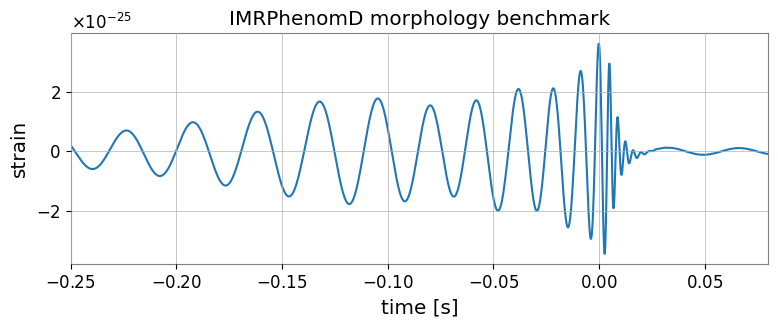

In [4]:

MSUN_SI = lal.MSUN_SI
PC_SI = lal.PC_SI

def make_imrphenomd_template(
    fs=4096.0,
    duration=2.0,
    m1_msun=36.0,
    m2_msun=29.0,
    distance_mpc=410.0,
    inclination=0.7,
    f_min=30.0
):
    n = int(2**np.ceil(np.log2(duration*fs)))
    duration = n/fs
    delta_f = 1.0/duration
    f_max = fs/2

    hp, hc = lalsim.SimInspiralChooseFDWaveform(
        m1_msun*MSUN_SI, m2_msun*MSUN_SI,
        0.0, 0.0, 0.0,
        0.0, 0.0, 0.0,
        distance_mpc*1e6*PC_SI,
        inclination,
        0.0, 0.0,
        0.0, 0.0,
        delta_f,
        f_min,
        f_max,
        f_min,
        None,
        lalsim.IMRPhenomD
    )

    H = np.asarray(hp.data.data, complex)
    target_bins = n//2 + 1

    if len(H) < target_bins:
        H = np.pad(H, (0, target_bins-len(H)))
    elif len(H) > target_bins:
        H = H[:target_bins]

    h = np.fft.irfft(H, n=n)
    peak = int(np.argmax(np.abs(h)))
    h = np.roll(h, n//2 - peak)
    h *= signal.windows.tukey(n, alpha=0.10)
    h = center(h)

    return h

template_phys = make_imrphenomd_template()
NSEG = len(template_phys)
SEG_DUR = NSEG/fs

print("template samples:", NSEG)
print("duration [s]:", SEG_DUR)

tt = (np.arange(NSEG)-NSEG//2)/fs
plt.figure(figsize=(9,3))
plt.plot(tt, template_phys)
plt.xlim(-0.25, 0.08)
plt.xlabel("time [s]")
plt.ylabel("strain")
plt.title("IMRPhenomD morphology benchmark")
plt.grid(True)
plt.show()


## 4 — Retard fractionnaire sans wrap

In [5]:

def fractional_delay(x, delay_s):
    """
    Convention:
        y(t) = x(t-delay_s)

    Positive delay => y arrives later.
    """
    x = np.asarray(x, float)
    n = len(x)

    pad = n
    xp = np.pad(x, (pad, pad))
    N = len(xp)

    f = np.fft.rfftfreq(N, 1/fs)
    X = np.fft.rfft(xp)
    Y = X*np.exp(-1j*2*np.pi*f*delay_s)

    yp = np.fft.irfft(Y, n=N)
    return yp[pad:pad+n]

imp = np.zeros(4096)
imp[2048] = 1.0

for tau_ms in [-10,-4,-1,1,4,10]:
    y = fractional_delay(imp, tau_ms*1e-3)
    measured = (np.argmax(y)-np.argmax(imp))/fs*1e3
    print(tau_ms, "ms ->", measured, "ms")
    assert abs(measured-tau_ms) <= (1/fs*1e3 + 1e-9)


-10 ms -> -10.009765625 ms
-4 ms -> -3.90625 ms
-1 ms -> -0.9765625 ms
1 ms -> 0.9765625 ms
4 ms -> 3.90625 ms
10 ms -> 10.009765625 ms


## 5 — Estimateurs temporels et de phase

In [6]:

MAX_LAG = 0.012

def parab(a, b, c):
    d = a - 2*b + c
    return 0.0 if d == 0 or not np.isfinite(d) else 0.5*(a-c)/d

def xcorr_lag(a, b):
    """
    Returns tau for b(t)=a(t-tau).
    """
    a = center(a)
    b = center(b)

    c = signal.correlate(a, b, mode="full", method="fft")
    lag = signal.correlation_lags(len(a), len(b), mode="full")/fs

    m = np.abs(lag) <= MAX_LAG
    cc = c[m]
    ll = lag[m]

    s = np.abs(cc)
    i = int(np.argmax(s))
    frac = parab(s[i-1], s[i], s[i+1]) if 0 < i < len(s)-1 else 0.0

    return float(-(ll[i] + frac/fs))

def phase_objects(a, b, nper=512):
    """
    scipy.signal.csd(a,b) = conj(A) B.
    If b(t)=a(t-tau), phase ≈ -2π f tau.
    """
    f, Pab = signal.csd(
        a, b, fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann"
    )

    _, coh = signal.coherence(
        a, b, fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann"
    )

    ph = np.angle(Pab)

    m = (
        (f >= 40)
        & (f <= 300)
        & np.isfinite(ph)
        & np.isfinite(coh)
    )

    return f[m], ph[m], coh[m]

def phase_slope_unwrap(a, b):
    f, ph, coh = phase_objects(a, b)

    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]

    if len(f) < 5:
        return np.nan

    pu = np.unwrap(ph)

    A = np.c_[f, np.ones_like(f)]
    W = np.sqrt(np.clip(w, 1e-12, None))

    beta, *_ = np.linalg.lstsq(
        A*W[:,None],
        pu*W,
        rcond=None
    )

    return float(-beta[0]/(2*np.pi))

def phase_circular_2pi_safe(a, b):
    f, ph, coh = phase_objects(a, b)

    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]

    if len(f) < 5:
        return np.nan

    grid = np.linspace(-MAX_LAG, MAX_LAG, 2401)
    z = np.exp(1j*ph)

    score = np.empty_like(grid)

    for i, tau in enumerate(grid):
        score[i] = np.abs(
            np.sum(
                w*z*np.exp(+1j*2*np.pi*f*tau)
            )
        )

    j = int(np.argmax(score))

    frac = (
        parab(score[j-1], score[j], score[j+1])
        if 0 < j < len(score)-1
        else 0.0
    )

    dtau = grid[1]-grid[0]

    return float(grid[j] + frac*dtau)


## 6 — GCC-PHAT V3 : régularisation relative

In [7]:

PHAT_REL_EPS = 1e-12

def phat_lag_relative(a, b, return_diagnostics=False):
    """
    GCC-PHAT V3 with relative regularization.

    G = A * conj(B)

    The absolute epsilon used previously is forbidden here.
    """
    a = center(a)
    b = center(b)

    n = int(2**np.ceil(np.log2(len(a)+len(b))))

    A = np.fft.rfft(a, n=n)
    B = np.fft.rfft(b, n=n)

    G = A*np.conj(B)
    mag = np.abs(G)

    max_mag = float(np.max(mag))
    eps_rel = PHAT_REL_EPS*max_mag if max_mag > 0 else np.finfo(float).tiny

    R = G/(mag + eps_rel)

    cc = np.fft.irfft(R, n=n)
    cc = np.concatenate((cc[-n//2:], cc[:n//2]))

    lag = np.arange(-n//2, n//2)/fs

    m = np.abs(lag) <= MAX_LAG
    ss = np.abs(cc[m])
    ll = lag[m]

    i = int(np.argmax(ss))
    frac = parab(ss[i-1], ss[i], ss[i+1]) if 0 < i < len(ss)-1 else 0.0

    tau = float(-(ll[i] + frac/fs))

    active = mag >= (1e-6*max_mag) if max_mag > 0 else np.zeros_like(mag, dtype=bool)

    if np.any(active):
        rel_reg_ratio = float(np.median(eps_rel/(mag[active] + eps_rel)))
        median_phat_norm = float(np.median(mag[active]/(mag[active] + eps_rel)))
    else:
        rel_reg_ratio = np.nan
        median_phat_norm = np.nan

    diagnostics = {
        "max_abs_G": max_mag,
        "epsilon_relative": float(eps_rel),
        "median_regularization_fraction_active_bins": rel_reg_ratio,
        "median_phat_normalization_active_bins": median_phat_norm,
        "n_active_bins": int(np.sum(active))
    }

    if return_diagnostics:
        return tau, diagnostics

    return tau


## 7 — Gate PHAT d'échelle numérique

In [8]:

phat_gate_rng = np.random.default_rng(7301)

u = phat_gate_rng.normal(size=NSEG)
sos_gate = signal.butter(
    4, [40,300],
    btype="bandpass",
    fs=fs,
    output="sos"
)
u = signal.sosfiltfilt(sos_gate, u)
u *= signal.windows.tukey(len(u), alpha=.10)

v = fractional_delay(u, 0.004)

tau_phat_test, phat_diag = phat_lag_relative(
    u, v, return_diagnostics=True
)

print("PHAT test lag [ms]:", tau_phat_test*1e3)
print(json.dumps(phat_diag, indent=2))

PHAT_SCALE_GATE = bool(
    abs(tau_phat_test*1e3 - 4.0) <= 0.35
    and phat_diag["n_active_bins"] > 10
    and phat_diag["median_regularization_fraction_active_bins"] < 1e-4
    and phat_diag["median_phat_normalization_active_bins"] > 0.999
)

print("PHAT_SCALE_GATE =", PHAT_SCALE_GATE)

if not PHAT_SCALE_GATE:
    raise RuntimeError(
        "GCC-PHAT relative-scale gate failed. Stop before realistic injections."
    )


PHAT test lag [ms]: 3.995124369269765
{
  "max_abs_G": 49518.045539579965,
  "epsilon_relative": 4.9518045539579964e-08,
  "median_regularization_fraction_active_bins": 7.718384558159837e-11,
  "median_phat_normalization_active_bins": 0.9999999999228162,
  "n_active_bins": 2068
}
PHAT_SCALE_GATE = True


## 8 — Gate unitaire complet de convention de signe

In [9]:

UNIT_DELAYS_MS = [-10,-4,-1,1,4,10]

unit_rows = []

for tau_ms in UNIT_DELAYS_MS:
    v = fractional_delay(u, tau_ms*1e-3)

    vals = {
        "xcorr": xcorr_lag(u,v)*1e3,
        "GCC-PHAT-relative": phat_lag_relative(u,v)*1e3,
        "phase_slope_unwrap": phase_slope_unwrap(u,v)*1e3,
        "phase_circular_2pi_safe": phase_circular_2pi_safe(u,v)*1e3
    }

    for est, val in vals.items():
        unit_rows.append({
            "tau_true_ms": tau_ms,
            "estimator": est,
            "tau_est_ms": val,
            "abs_error_ms": abs(val-tau_ms)
        })

unit_df = pd.DataFrame(unit_rows)
display(unit_df)

UNIT_MAX_ERROR_MS = (
    unit_df
    .groupby("estimator")
    .abs_error_ms
    .max()
)

print(UNIT_MAX_ERROR_MS)

UNIT_SIGN_GATE = bool(
    (UNIT_MAX_ERROR_MS <= 0.35).all()
)

print("UNIT_SIGN_GATE =", UNIT_SIGN_GATE)

if not UNIT_SIGN_GATE:
    raise RuntimeError(
        "Delay/sign convention gate failed."
    )


,tau_true_ms,estimator,tau_est_ms,abs_error_ms
0,-10,xcorr,-10.000099,0.000099
1,-10,GCC-PHAT-relative,-10.001669,0.001669
2,-10,phase_slope_unwrap,-9.947053,0.052947
3,-10,phase_circular_2pi_safe,-9.947120,0.052880
4,-4,xcorr,-3.999605,0.000395
5,-4,GCC-PHAT-relative,-3.996430,0.003570
6,-4,phase_slope_unwrap,-3.979139,0.020861
7,-4,phase_circular_2pi_safe,-3.979144,0.020856
8,-1,xcorr,-0.999770,0.000230
9,-1,GCC-PHAT-relative,-0.995904,0.004096


estimator
GCC-PHAT-relative          0.004876
phase_circular_2pi_safe    0.052880
phase_slope_unwrap         0.052947
xcorr                      0.000395
Name: abs_error_ms, dtype: float64
UNIT_SIGN_GATE = True


## 9 — Fenêtres RAW off-source

In [10]:

CENTERS = [-12.0,-9.0,-6.0,-3.0,3.0,6.0,9.0,12.0]

def segment_around_raw(x, center_s, n=NSEG):
    c = int(np.argmin(np.abs(t_rel-center_s)))
    a = c - n//2
    b = a + n

    if a < 0 or b > len(x):
        return None

    return np.array(x[a:b], float)

noise_pairs = []

for c in CENTERS:
    nh = segment_around_raw(h1, c)
    nl = segment_around_raw(l1, c)

    if (
        nh is not None
        and nl is not None
        and len(nh) == NSEG
        and len(nl) == NSEG
    ):
        noise_pairs.append((c,nh,nl))

print("RAW off-source pairs:", len(noise_pairs))
assert len(noise_pairs) >= 6


RAW off-source pairs: 8


## 10 — PSD et SNR optimal

In [11]:

SNR_FMIN = 35.0
SNR_FMAX = 350.0

def estimate_noise_psd(noise_raw):
    nper = min(2048, len(noise_raw))

    f, P = signal.welch(
        center(noise_raw),
        fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann",
        detrend="constant",
        scaling="density",
        average="median"
    )

    floor = np.finfo(float).tiny
    return f, np.maximum(P, floor)

def optimal_snr_timeseries(h, f_psd, P):
    h = np.asarray(h,float)

    n = len(h)
    dt = 1/fs

    f = np.fft.rfftfreq(n,dt)
    Hc = dt*np.fft.rfft(h)

    Pi = np.interp(
        f, f_psd, P,
        left=P[0],
        right=P[-1]
    )

    df = fs/n

    m = (
        (f >= SNR_FMIN)
        & (f <= SNR_FMAX)
        & np.isfinite(Pi)
        & (Pi > 0)
    )

    rho2 = 4*np.sum(
        np.abs(Hc[m])**2/Pi[m]
    )*df

    return float(np.sqrt(max(rho2,0.0)))


## 11 — Calibration du SNR réseau

In [12]:

NETWORK_SNRS = [8.0,12.0,20.0]
DELAYS_MS = np.array([-10,-7,-4,-1,0,1,4,7,10], float)

def calibrate_network_amplitude(
    template,
    noise_h_raw,
    noise_l_raw,
    response_ratio,
    target_rho
):
    fh, Ph = estimate_noise_psd(noise_h_raw)
    fl, Pl = estimate_noise_psd(noise_l_raw)

    rho_h_unit = optimal_snr_timeseries(
        template, fh, Ph
    )

    rho_l_unit = optimal_snr_timeseries(
        template, fl, Pl
    )

    denom = np.sqrt(
        rho_h_unit**2
        +
        (abs(response_ratio)*rho_l_unit)**2
    )

    if not np.isfinite(denom) or denom <= 0:
        raise ValueError(
            "Invalid SNR calibration denominator."
        )

    A = target_rho/denom

    achieved = np.sqrt(
        (A*rho_h_unit)**2
        +
        (A*abs(response_ratio)*rho_l_unit)**2
    )

    return (
        float(A),
        float(achieved),
        float(rho_h_unit),
        float(rho_l_unit)
    )



## 12 — Matched filter PSD-weighted oracle

Le contrôle oracle utilise le **template exact injecté** et la PSD locale du détecteur.

On filtre séparément H1 et L1 :

\[
z_O(\tau)
\propto
\mathcal F^{-1}
\left[
\frac{\tilde s_O(f)\tilde h_O^*(f)}
{S_{n,O}(f)}
\right].
\]

La position temporelle de l'injection est connue dans ce benchmark contrôlé ; la recherche du maximum est donc bornée à :

\[
|\Delta t_{\rm search}|\le 30\ {\rm ms}
\]

autour de la position nominale du template.

Ce contrôle est un **oracle d'injection**, pas un estimateur aveugle du véritable GW150914.


In [13]:

MF_SEARCH_HALF_WIDTH = 0.030

def psd_whiten_for_matched_filter(x, f_psd, P):
    """
    Frequency-domain inverse-sqrt-PSD weighting.
    Overall normalization is irrelevant for lag location.
    """
    x = center(np.asarray(x,float))

    n = len(x)
    f = np.fft.rfftfreq(n,1/fs)

    X = np.fft.rfft(x)

    Pi = np.interp(
        f, f_psd, P,
        left=P[0],
        right=P[-1]
    )

    mask = (
        (f >= SNR_FMIN)
        & (f <= SNR_FMAX)
        & np.isfinite(Pi)
        & (Pi > 0)
    )

    W = np.zeros_like(X, dtype=complex)
    W[mask] = X[mask]/np.sqrt(Pi[mask])

    return np.fft.irfft(W,n=n)

def matched_filter_arrival_shift(
    data_raw,
    template_raw,
    f_psd,
    P,
    search_half_width=MF_SEARCH_HALF_WIDTH
):
    """
    Return shift of data signal relative to centered template.
    Positive => signal appears later than template.
    """
    dw = psd_whiten_for_matched_filter(
        data_raw, f_psd, P
    )

    tw = psd_whiten_for_matched_filter(
        template_raw, f_psd, P
    )

    c = signal.correlate(
        dw, tw,
        mode="full",
        method="fft"
    )

    lags = signal.correlation_lags(
        len(dw), len(tw),
        mode="full"
    )/fs

    m = np.abs(lags) <= search_half_width

    cc = np.abs(c[m])
    ll = lags[m]

    i = int(np.argmax(cc))

    frac = (
        parab(
            cc[i-1],
            cc[i],
            cc[i+1]
        )
        if 0 < i < len(cc)-1
        else 0.0
    )

    return float(
        ll[i] + frac/fs
    )

def matched_filter_psd_oracle_relative_lag(
    H_raw,
    L_raw,
    template_h_raw,
    template_l_reference_raw,
    fh, Ph,
    fl, Pl
):
    """
    Exact injection-template oracle.

    H arrival shift is measured relative to H template.
    L arrival shift is measured relative to the *undelayed*
    L morphology/reference template.

    Their difference estimates L-H delay.
    """
    shift_h = matched_filter_arrival_shift(
        H_raw,
        template_h_raw,
        fh, Ph
    )

    shift_l = matched_filter_arrival_shift(
        L_raw,
        template_l_reference_raw,
        fl, Pl
    )

    return float(
        shift_l-shift_h
    )


## 13 — Gate unitaire du matched filter

In [15]:
# ============================================================
# RACC-C.4-real.2.14-V3
# FIX — Matched-filter unit timing/sign gate
# ============================================================

# The unit gate must test the estimator itself.
# It must NOT contain identical correlated H/L noise.

base = template_phys / (
    np.std(template_phys) + np.finfo(float).eps
)

# Independent PSD-estimation noise.
# This noise is used ONLY to construct a non-trivial PSD,
# not added identically to H and L.
mf_psd_rng = np.random.default_rng(7313)

noise_psd_h = mf_psd_rng.normal(
    0.0, 1.0, size=NSEG
)

noise_psd_l = mf_psd_rng.normal(
    0.0, 1.0, size=NSEG
)

f_h_test, P_h_test = estimate_noise_psd(noise_psd_h)
f_l_test, P_l_test = estimate_noise_psd(noise_psd_l)

mf_unit_rows = []

for tau_ms in [-10, -4, -1, 1, 4, 10]:

    tau_s = tau_ms * 1e-3

    # Pure controlled injection.
    # H = reference arrival
    # L = known delayed/advanced arrival
    Ht = base.copy()

    Lt = fractional_delay(
        base,
        tau_s
    )

    est_s = matched_filter_psd_oracle_relative_lag(
        Ht,
        Lt,
        base,
        base,
        f_h_test,
        P_h_test,
        f_l_test,
        P_l_test
    )

    est_ms = est_s * 1e3

    mf_unit_rows.append({
        "tau_true_ms": tau_ms,
        "tau_est_ms": est_ms,
        "error_ms": est_ms - tau_ms,
        "abs_error_ms": abs(est_ms - tau_ms)
    })

mf_unit_df = pd.DataFrame(mf_unit_rows)

display(mf_unit_df)

MF_MAX_ERROR_MS = float(
    mf_unit_df["abs_error_ms"].max()
)

MATCHED_FILTER_UNIT_GATE = bool(
    MF_MAX_ERROR_MS <= 0.35
)

print(
    "MF_MAX_ERROR_MS =",
    MF_MAX_ERROR_MS
)

print(
    "MATCHED_FILTER_UNIT_GATE =",
    MATCHED_FILTER_UNIT_GATE
)

if not MATCHED_FILTER_UNIT_GATE:
    raise RuntimeError(
        "PSD matched-filter timing/sign convention still failed. "
        "Do not execute realistic injections."
    )

,tau_true_ms,tau_est_ms,error_ms,abs_error_ms
0,-10,-10.000063,-0.000063,0.000063
1,-4,-3.999727,0.000273,0.000273
2,-1,-0.999840,0.000160,0.000160
3,1,0.999840,-0.000160,0.000160
4,4,3.999715,-0.000285,0.000285
5,10,10.000067,0.000067,0.000067


MF_MAX_ERROR_MS = 0.0002852187290383057
MATCHED_FILTER_UNIT_GATE = True


## 14 — Matrice d'injections réalistes V3

In [16]:

rows = []

for center_s, nh_raw, nl_raw in noise_pairs:

    fh, Ph = estimate_noise_psd(nh_raw)
    fl, Pl = estimate_noise_psd(nl_raw)

    for rho_target in NETWORK_SNRS:

        response_ratio = float(
            RNG.uniform(0.65,1.35)
        )

        polarity = float(
            RNG.choice([-1.0,1.0])
        )

        A, rho_achieved, rho_h_unit, rho_l_unit = (
            calibrate_network_amplitude(
                template_phys,
                nh_raw,
                nl_raw,
                response_ratio,
                rho_target
            )
        )

        # Undelayed detector-specific morphology for oracle.
        h_template_raw = A*template_phys
        l_template_reference_raw = (
            polarity
            * response_ratio
            * A
            * template_phys
        )

        for delay_ms in DELAYS_MS:

            tau = delay_ms*1e-3

            h_inj = h_template_raw

            l_inj = (
                polarity
                * response_ratio
                * A
                * fractional_delay(
                    template_phys,
                    tau
                )
            )

            H_raw_injected = nh_raw + h_inj
            L_raw_injected = nl_raw + l_inj

            # Same P after injection for all non-oracle estimators.
            H = preprocessing_P(H_raw_injected)
            L = preprocessing_P(L_raw_injected)

            phat_value, phat_diag_local = (
                phat_lag_relative(
                    H,L,
                    return_diagnostics=True
                )
            )

            estimates = {
                "xcorr":
                    xcorr_lag(H,L),

                "GCC-PHAT-relative":
                    phat_value,

                "phase_slope_unwrap":
                    phase_slope_unwrap(H,L),

                "phase_circular_2pi_safe":
                    phase_circular_2pi_safe(H,L),

                "matched_filter_psd_oracle":
                    matched_filter_psd_oracle_relative_lag(
                        H_raw_injected,
                        L_raw_injected,
                        h_template_raw,
                        l_template_reference_raw,
                        fh,Ph,
                        fl,Pl
                    )
            }

            rho_h = optimal_snr_timeseries(
                h_inj,fh,Ph
            )

            rho_l = optimal_snr_timeseries(
                l_inj,fl,Pl
            )

            rho_net_check = float(
                np.sqrt(
                    rho_h**2
                    +
                    rho_l**2
                )
            )

            for est,val in estimates.items():
                rows.append({
                    "noise_center_s":center_s,
                    "rho_network_target":rho_target,
                    "rho_network_check":rho_net_check,
                    "response_ratio":response_ratio,
                    "polarity":polarity,
                    "delay_injected_ms":delay_ms,
                    "estimator":est,
                    "delay_estimated_ms":
                        val*1e3
                        if np.isfinite(val)
                        else np.nan,
                    "error_ms":
                        val*1e3-delay_ms
                        if np.isfinite(val)
                        else np.nan,
                    "phat_eps_relative":
                        phat_diag_local["epsilon_relative"]
                        if est == "GCC-PHAT-relative"
                        else np.nan,
                    "phat_regularization_fraction":
                        phat_diag_local["median_regularization_fraction_active_bins"]
                        if est == "GCC-PHAT-relative"
                        else np.nan
                })

inj_df = pd.DataFrame(rows)

expected = (
    len(noise_pairs)
    * len(NETWORK_SNRS)
    * len(DELAYS_MS)
    * 5
)

print("rows:",len(inj_df))
print("expected rows:",expected)

snr_cal_error = np.median(
    np.abs(
        inj_df.rho_network_check
        -
        inj_df.rho_network_target
    )
)

print(
    "median |rho_check-target|:",
    snr_cal_error
)

display(inj_df.head(12))


rows: 1080
expected rows: 1080
median |rho_check-target|: 3.032140742931233e-07


,noise_center_s,rho_network_target,rho_network_check,response_ratio,polarity,delay_injected_ms,estimator,delay_estimated_ms,error_ms,phat_eps_relative,phat_regularization_fraction
0,-12.0,8.0,7.999998,1.042131,-1.0,-10.0,xcorr,-0.339107,9.660893,NaN,NaN
1,-12.0,8.0,7.999998,1.042131,-1.0,-10.0,GCC-PHAT-relative,0.016951,10.016951,3.064289e-48,1.592175e-07
2,-12.0,8.0,7.999998,1.042131,-1.0,-10.0,phase_slope_unwrap,NaN,NaN,NaN,NaN
3,-12.0,8.0,7.999998,1.042131,-1.0,-10.0,phase_circular_2pi_safe,NaN,NaN,NaN,NaN
4,-12.0,8.0,7.999998,1.042131,-1.0,-10.0,matched_filter_psd_oracle,-7.982617,2.017383,NaN,NaN
5,-12.0,8.0,8.000001,1.042131,-1.0,-7.0,xcorr,-0.341425,6.658575,NaN,NaN
6,-12.0,8.0,8.000001,1.042131,-1.0,-7.0,GCC-PHAT-relative,0.016945,7.016945,3.042537e-48,1.580873e-07
7,-12.0,8.0,8.000001,1.042131,-1.0,-7.0,phase_slope_unwrap,NaN,NaN,NaN,NaN
8,-12.0,8.0,8.000001,1.042131,-1.0,-7.0,phase_circular_2pi_safe,NaN,NaN,NaN,NaN
9,-12.0,8.0,8.000001,1.042131,-1.0,-7.0,matched_filter_psd_oracle,-8.013465,-1.013465,NaN,NaN


## 15 — Diagnostic spécifique PHAT V3

In [17]:

phat_diag_df = inj_df[
    inj_df.estimator=="GCC-PHAT-relative"
].copy()

print(
    "Median PHAT regularization fraction:",
    np.nanmedian(
        phat_diag_df.phat_regularization_fraction
    )
)

PHAT_REAL_SCALE_GATE = bool(
    np.nanmedian(
        phat_diag_df.phat_regularization_fraction
    ) < 1e-4
)

# Check whether PHAT and xcorr are numerically identical to machine precision.
pivot_lags = (
    inj_df[
        inj_df.estimator.isin(
            ["xcorr","GCC-PHAT-relative"]
        )
    ]
    .pivot_table(
        index=[
            "noise_center_s",
            "rho_network_target",
            "delay_injected_ms"
        ],
        columns="estimator",
        values="delay_estimated_ms"
    )
    .dropna()
)

lag_delta = (
    pivot_lags["GCC-PHAT-relative"]
    -
    pivot_lags["xcorr"]
)

PHAT_XCORR_IDENTICAL_FRACTION = float(
    np.mean(
        np.abs(lag_delta) < 1e-9
    )
)

PHAT_DISTINCT_FROM_XCORR = bool(
    PHAT_XCORR_IDENTICAL_FRACTION < 0.99
)

print(
    "PHAT_XCORR_IDENTICAL_FRACTION =",
    PHAT_XCORR_IDENTICAL_FRACTION
)

print(
    "PHAT_DISTINCT_FROM_XCORR =",
    PHAT_DISTINCT_FROM_XCORR
)

print(
    "PHAT_REAL_SCALE_GATE =",
    PHAT_REAL_SCALE_GATE
)


Median PHAT regularization fraction: 1.0794231128948806e-07
PHAT_XCORR_IDENTICAL_FRACTION = 0.0
PHAT_DISTINCT_FROM_XCORR = True
PHAT_REAL_SCALE_GATE = True


## 16 — Calibration globale

In [ ]:

def robust_sigma(x):
    x = np.asarray(x,float)
    med = np.nanmedian(x)

    return float(
        1.4826
        *
        np.nanmedian(
            np.abs(x-med)
        )
    )

summary_rows = []

for est,d in inj_df.groupby("estimator"):

    e = d.error_ms.to_numpy(float)
    e = e[np.isfinite(e)]

    summary_rows.append({
        "estimator":est,
        "n_eff":int(len(e)),
        "median_bias_ms":
            float(np.median(e)),
        "mean_bias_ms":
            float(np.mean(e)),
        "robust_sigma_ms":
            robust_sigma(e),
        "rmse_ms":
            float(np.sqrt(np.mean(e**2))),
        "p90_abs_error_ms":
            float(np.percentile(np.abs(e),90)),
        "success_abs2ms":
            float(np.mean(np.abs(e)<=2.0)),
        "success_abs1ms":
            float(np.mean(np.abs(e)<=1.0))
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("rmse_ms")
)

display(summary_df)


## 17 — Performance par SNR réseau

In [ ]:

snr_rows = []

for (est,rho),d in inj_df.groupby(
    ["estimator","rho_network_target"]
):
    e = d.error_ms.dropna().to_numpy(float)

    snr_rows.append({
        "estimator":est,
        "rho_network":float(rho),
        "n_eff":int(len(e)),
        "median_bias_ms":
            float(np.median(e)),
        "robust_sigma_ms":
            robust_sigma(e),
        "rmse_ms":
            float(np.sqrt(np.mean(e**2))),
        "p90_abs_error_ms":
            float(np.percentile(np.abs(e),90)),
        "success_abs2ms":
            float(np.mean(np.abs(e)<=2.0))
    })

snr_df = pd.DataFrame(snr_rows)
display(snr_df)


## 18 — Symétrie positive / négative

In [ ]:

sign_rows = []

for est,d in inj_df.groupby("estimator"):

    neg = (
        d[d.delay_injected_ms<0]
        .error_ms
        .dropna()
        .to_numpy(float)
    )

    pos = (
        d[d.delay_injected_ms>0]
        .error_ms
        .dropna()
        .to_numpy(float)
    )

    sign_rows.append({
        "estimator":est,
        "median_error_negative_ms":
            float(np.median(neg))
            if len(neg)
            else np.nan,
        "median_error_positive_ms":
            float(np.median(pos))
            if len(pos)
            else np.nan,
        "sign_bias_gap_ms":
            float(
                abs(
                    np.median(pos)
                    -
                    np.median(neg)
                )
            )
            if len(pos) and len(neg)
            else np.nan
    })

sign_df = pd.DataFrame(sign_rows)
display(sign_df)


## 19 — Estimé versus injecté

In [ ]:

plot_df = inj_df[
    inj_df.estimator!="matched_filter_psd_oracle"
]

plt.figure(figsize=(8,6))

for est,d in plot_df.groupby("estimator"):

    g = (
        d.groupby("delay_injected_ms")
        .delay_estimated_ms
        .median()
    )

    plt.plot(
        g.index,
        g.values,
        marker="o",
        label=est
    )

plt.plot(
    DELAYS_MS,
    DELAYS_MS,
    "--",
    label="truth"
)

plt.xlabel("Injected delay [ms]")
plt.ylabel("Median estimated delay [ms]")
plt.title("V3 realistic injections")
plt.grid(True)
plt.legend()
plt.show()


## 20 — Gate de qualification V3

In [ ]:

QUAL_THRESH = {
    "abs_median_bias_ms":0.5,
    "robust_sigma_ms":1.5,
    "success_abs2ms":0.80,
    "p90_abs_error_ms":3.0,
    "rho8_success_abs2ms":0.60,
    "rho8_p90_abs_error_ms":5.0
}

NON_ORACLE = [
    "xcorr",
    "GCC-PHAT-relative",
    "phase_slope_unwrap",
    "phase_circular_2pi_safe"
]

qual_rows = []

for _,r in summary_df.iterrows():

    if r.estimator not in NON_ORACLE:
        continue

    low = snr_df[
        (snr_df.estimator==r.estimator)
        &
        (
            snr_df.rho_network
            ==
            min(NETWORK_SNRS)
        )
    ].iloc[0]

    qualified = bool(
        abs(r.median_bias_ms)
            <= QUAL_THRESH["abs_median_bias_ms"]

        and r.robust_sigma_ms
            <= QUAL_THRESH["robust_sigma_ms"]

        and r.success_abs2ms
            >= QUAL_THRESH["success_abs2ms"]

        and r.p90_abs_error_ms
            <= QUAL_THRESH["p90_abs_error_ms"]

        and low.success_abs2ms
            >= QUAL_THRESH["rho8_success_abs2ms"]

        and low.p90_abs_error_ms
            <= QUAL_THRESH["rho8_p90_abs_error_ms"]
    )

    qual_rows.append({
        "estimator":r.estimator,
        "qualified":qualified,
        "abs_median_bias_ms":
            abs(r.median_bias_ms),
        "robust_sigma_ms":
            r.robust_sigma_ms,
        "rmse_ms":
            r.rmse_ms,
        "p90_abs_error_ms":
            r.p90_abs_error_ms,
        "success_abs2ms":
            r.success_abs2ms,
        "rho8_success_abs2ms":
            low.success_abs2ms,
        "rho8_p90_abs_error_ms":
            low.p90_abs_error_ms
    })

qual_df = (
    pd.DataFrame(qual_rows)
    .sort_values(
        ["qualified","rmse_ms"],
        ascending=[False,True]
    )
)

display(qual_df)


## 21 — Contrôle oracle PSD

In [ ]:

oracle = summary_df[
    summary_df.estimator=="matched_filter_psd_oracle"
].copy()

display(oracle)

if len(oracle):
    oracle_rmse = float(
        oracle.iloc[0].rmse_ms
    )

    oracle_p90 = float(
        oracle.iloc[0].p90_abs_error_ms
    )

    MATCHED_FILTER_ORACLE_STABLE = bool(
        np.isfinite(oracle_rmse)
        and np.isfinite(oracle_p90)
        and oracle_rmse < 10.0
        and oracle_p90 < 15.0
    )
else:
    MATCHED_FILTER_ORACLE_STABLE = False

print(
    "MATCHED_FILTER_ORACLE_STABLE =",
    MATCHED_FILTER_ORACLE_STABLE
)


## 22 — Gestion explicite des égalités

In [ ]:

qualified_df = qual_df[
    qual_df.qualified==True
].copy()

if len(qualified_df) == 0:

    WINNERS = []

    FINAL_STATUS = (
        "NO-ESTIMATOR-PASSES-QUALIFICATION-GATE"
    )

else:

    best_rmse = float(
        qualified_df.rmse_ms.min()
    )

    TIE_TOL_MS = 0.05

    tied = qualified_df[
        np.abs(
            qualified_df.rmse_ms
            -
            best_rmse
        )
        <= TIE_TOL_MS
    ].copy()

    WINNERS = tied.estimator.tolist()

    if len(WINNERS) == 1:

        FINAL_STATUS = (
            "ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS-V3"
        )

    else:

        FINAL_STATUS = (
            "MULTIPLE-ESTIMATORS-QUALIFIED-NO-UNIQUE-WINNER"
        )

print("WINNERS =",WINNERS)
print("FINAL_STATUS =",FINAL_STATUS)


## 23 — Diagnostic V3

In [ ]:

diagnostic_v3 = {
    "UNIT_SIGN_GATE":
        UNIT_SIGN_GATE,

    "PHAT_SCALE_GATE":
        PHAT_SCALE_GATE,

    "PHAT_REAL_SCALE_GATE":
        PHAT_REAL_SCALE_GATE,

    "PHAT_DISTINCT_FROM_XCORR":
        PHAT_DISTINCT_FROM_XCORR,

    "PHAT_XCORR_IDENTICAL_FRACTION":
        PHAT_XCORR_IDENTICAL_FRACTION,

    "MATCHED_FILTER_UNIT_GATE":
        MATCHED_FILTER_UNIT_GATE,

    "MATCHED_FILTER_ORACLE_STABLE":
        MATCHED_FILTER_ORACLE_STABLE,

    "median_network_snr_calibration_abs_error":
        float(snr_cal_error),

    "injection_before_preprocessing":
        True,

    "snr_is_psd_weighted_optimal_network_snr":
        True,

    "phat_regularization":
        "relative_1e-12_times_max_abs_cross_spectrum",

    "matched_filter":
        "inverse_sqrt_PSD_weighted_local_oracle",

    "tie_handling_explicit":
        True
}

print(
    json.dumps(
        diagnostic_v3,
        indent=2
    )
)


## 24 — Verdict machine-readable

In [ ]:

oracle_record = (
    oracle.iloc[0].to_dict()
    if len(oracle)
    else {}
)

artifact = {
    "step":
        "RACC-C.4-real.2.14-V3",

    "event_context":
        "GW150914 H1/L1 RAW off-source real noise",

    "waveform":
        "IMRPhenomD",

    "phase_convention":
        "scipy.csd(a,b)=conj(A)B; tau=-slope/(2pi)",

    "phat_convention":
        "A*conj(B), relative epsilon",

    "delay_grid_ms":
        DELAYS_MS.tolist(),

    "network_snr_targets":
        NETWORK_SNRS,

    "offsource_centers_s":
        CENTERS,

    "n_noise_pairs":
        len(noise_pairs),

    "n_total_estimates":
        int(len(inj_df)),

    "qualification_thresholds":
        QUAL_THRESH,

    "qualified_estimators":
        qualified_df.estimator.tolist()
        if len(qualified_df)
        else [],

    "winner_or_tied_winners":
        WINNERS,

    "diagnostic_v3":
        diagnostic_v3,

    "final_status":
        FINAL_STATUS,

    "oracle_control":
        oracle_record,

    "TIMING_VALIDATED":
        False,

    "D_T_ref":
        "NOT-AUTHORIZED",

    "REAL3_AUTHORIZED":
        False,

    "DISPERSION_READY_modified":
        False,

    "HH_chain_modified":
        False,

    "core_GVH_modified":
        False,

    "HH_central":
        "BLOCKED-PENDING-.1.6"
}

print(
    json.dumps(
        artifact,
        indent=2,
        default=float
    )
)

Path(
    "racc_c4_real_2_14_v3_verdict.json"
).write_text(
    json.dumps(
        artifact,
        indent=2,
        default=float
    )
)

summary_df.to_csv(
    "racc_c4_real_2_14_v3_summary.csv",
    index=False
)

snr_df.to_csv(
    "racc_c4_real_2_14_v3_by_snr.csv",
    index=False
)

qual_df.to_csv(
    "racc_c4_real_2_14_v3_qualification.csv",
    index=False
)

sign_df.to_csv(
    "racc_c4_real_2_14_v3_sign_symmetry.csv",
    index=False
)



## 25 — Interprétation autorisée

### Cas A — Aucun estimateur ne passe

\[
\boxed{
\texttt{NO-ESTIMATOR-PASSES-QUALIFICATION-GATE}
}
\]

Cela signifie que la correction PHAT et le nouvel oracle n'ont pas suffi à qualifier un estimateur dans la matrice réaliste V3.

### Cas B — Un seul estimateur passe

\[
\boxed{
\texttt{ESTIMATOR-QUALIFIED-ON-REALISTIC-INJECTIONS-V3}
}
\]

Qualification méthodologique seulement.

### Cas C — Plusieurs estimateurs passent sans séparation claire

\[
\boxed{
\texttt{MULTIPLE-ESTIMATORS-QUALIFIED-NO-UNIQUE-WINNER}
}
\]

Aucun gagnant artificiel n'est créé par l'ordre d'un DataFrame.

---

## Interdictions d'interprétation

Même dans le meilleur cas, V3 ne permet pas d'affirmer :

- un retard H1↔L1 physiquement validé pour GW150914 ;
- une violation de GR ;
- un retard GVH ;
- une propagation gravitationnelle anormale ;
- une valeur autorisée de \(D_T^{ref}\) ;
- l'ouverture de `real.3`.

---

## Gates finaux

\[
\boxed{
\texttt{TIMING-VALIDATED=False}
}
\]

\[
\boxed{
D_T^{ref}=\texttt{NOT-AUTHORIZED}
}
\]

\[
\boxed{
\texttt{REAL3-AUTHORIZED=False}
}
\]

\[
\boxed{
R_{HH}=\texttt{BLOCKED-PENDING-.1.6}
}
\]

La décision sur `real.2.15` ne doit être prise qu'après lecture du verdict exécuté de ce notebook.
